# PIMA INDIAN DIABETES CLASSIFICATION
**Dữ liệu**: Pima Indians Diabetes Dataset — 768 mẫu, 8 đặc trưng y tế, nhãn nhị phân (có/không bị tiểu đường).

### Khai báo thư viện

In [4]:
import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Thư viện đã được nạp thành công.")

Thư viện đã được nạp thành công.


## 1. Nạp dữ liệu
- Thiết lập đường dẫn lưu trữ các hình vẽ xuất ra (report_path) và đường dẫn tệp dữ liệu CSV.

- Sử dụng pd.read_csv() để đọc dữ liệu. Vì tệp gốc có thể không có dòng tiêu đề, mã nguồn đã định nghĩa danh sách col_names để gán tên cột rõ ràng cho DataFrame (như Glucose, Insulin, BMI, Age...).

In [5]:
report_path = os.path.join(os.getcwd(), "..", "docs", "figures")
os.makedirs(report_path, exist_ok=True)
data_path = os.path.join(os.getcwd(), "..", "data", "pima-indians-diabetes.csv")
data_path = os.path.abspath(data_path)

col_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
df = pd.read_csv(data_path, header=None, names=col_names)
print(f"Đã nạp {len(df)} dòng dữ liệu.")
print(f"Kích thước của DataFrame: {df.shape[0]} dòng và {df.shape[1]} cột.")
df.head(10)

Đã nạp 768 dòng dữ liệu.
Kích thước của DataFrame: 768 dòng và 9 cột.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## 2. Phân tích khám phá dữ liệu - EDA

### 2.1 Thống kê mô tả
- df.describe(): Cung cấp cái nhìn tổng quan về các chỉ số thống kê của từng cột số: giá trị trung bình (mean), độ lệch chuẩn (std), giá trị nhỏ nhất/lớn nhất và các mốc tứ phân vị (25%, 50%, 75%).

- df.info(): Kiểm tra kiểu dữ liệu của từng cột (int64, float64) và xem có bao nhiêu giá trị không bị khuyết (non-null).

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### 2.2 Kiểm tra tính toàn vẹn dữ liệu
- Kiểm tra dữ liệu thiếu (Missing Values): Trong tập dữ liệu này, một số cột như Insulin hay BMI có giá trị bằng 0 một cách vô lý về mặt sinh học. Mã nguồn đã thống kê các giá trị 0 này, vẽ biểu đồ cột để thấy mức độ thiếu hụt, sau đó thay thế chúng bằng giá trị NaN (giá trị rỗng thực sự) để xử lý ở các bước sau.

- Kiểm tra dữ liệu trùng (Duplicate Data): Sử dụng df.duplicated() để đảm bảo không có dòng dữ liệu nào bị lặp lại, tránh làm sai lệch kết quả phân tích.

#### 2.2.1 Kiểm tra dữ liệu thiếu

Cột có giá trị 0 (xem như thiếu):


,Count,%
Insulin,374,48.70
SkinThickness,227,29.56
BloodPressure,35,4.56
BMI,11,1.43
Glucose,5,0.65


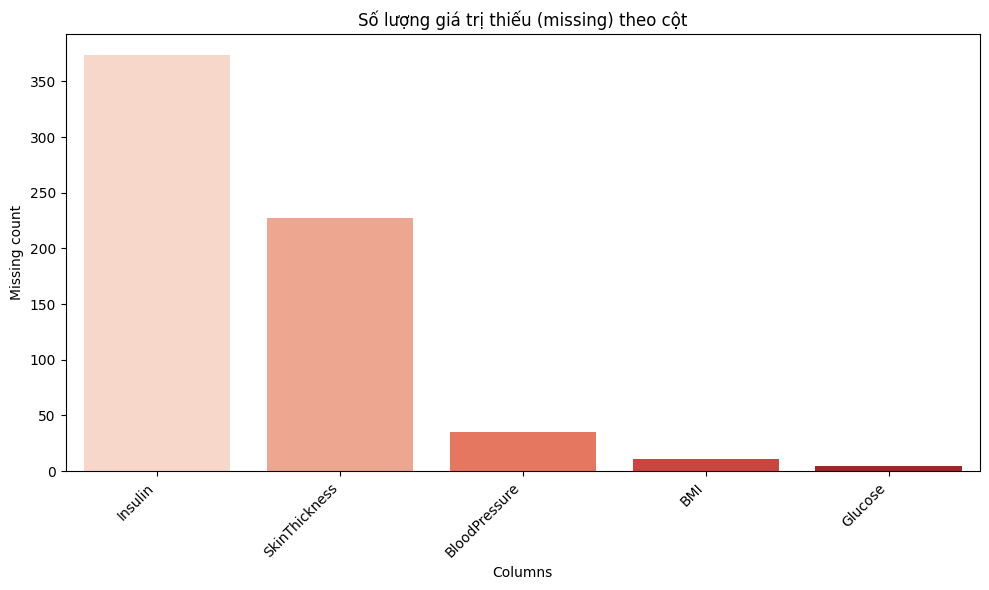

In [8]:
# Kiểm tra thiếu dữ liệu
cols_to_check = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
zero_counts = (df[cols_to_check] == 0).sum()
zero_pct = (zero_counts / len(df) * 100).round(2)

zero_df = pd.DataFrame({
    "Count": zero_counts,
    "%": zero_pct
})

# Lọc chỉ những cột có giá trị 0 và sắp xếp theo phần trăm
zero_df = zero_df[zero_df["Count"] > 0].sort_values("%", ascending=False)

if zero_df.empty:
    print("Không có giá trị 0 trong dataset.")
else:
    print("Cột có giá trị 0 (xem như thiếu):")
    display(zero_df)

    # Biểu đồ cột count
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=zero_df.index,
        y="Count",
        data=zero_df,
        palette="Reds"
    )
    plt.title("Số lượng giá trị thiếu (missing) theo cột")
    plt.ylabel("Missing count")
    plt.xlabel("Columns")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(report_path, "missing_values_count.png"))
    plt.show()

# Xử lý giá trị thiếu bằng cách thay thế 0 bằng NaN
cols_to_replace = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols_to_replace] = df[cols_to_replace].replace(0, np.nan)

#### 2.2.2 Kiểm tra dữ liệu trùng

In [9]:
# Tìm số dòng trùng
dup_mask = df.duplicated(keep=False)  # keep=False để đánh dấu mọi dòng trùng
dup_rows = df[dup_mask]

print("Tổng dòng trùng:", dup_rows.shape[0])

# Hiển thị dòng trùng
if (not dup_rows.empty):
    display(dup_rows)

Tổng dòng trùng: 0


### 2.3 Phân bố Outcome
- Phân tích cột Outcome (0: không bị bệnh, 1: bị bệnh).

- Mã nguồn tính toán số lượng và phần trăm của từng lớp, sau đó vẽ biểu đồ cột (Bar plot) để kiểm tra xem dữ liệu có bị mất cân bằng (Imbalance) hay không. Ở đây, lớp 0 chiếm khoảng 65.1%, cho thấy dữ liệu có sự chênh lệch giữa hai nhóm.

Phân bố lớp Outcome:


,count,percent
Outcome,,
0,500,65.1
1,268,34.9


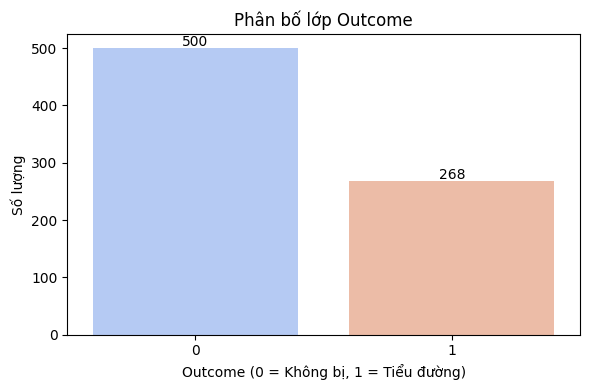

In [10]:
# Phân bố lớp Outcome
outcome_counts = df["Outcome"].value_counts().sort_index()
outcome_pct = (outcome_counts / len(df) * 100).round(2)

outcome_df = pd.DataFrame({
    "count": outcome_counts,
    "percent": outcome_pct
})

print("Phân bố lớp Outcome:")
display(outcome_df)

plt.figure(figsize=(6, 4))
sns.barplot(x=outcome_df.index.astype(str), y="count", data=outcome_df, palette="coolwarm")
plt.title("Phân bố lớp Outcome")
plt.xlabel("Outcome (0 = Không bị, 1 = Tiểu đường)")
plt.ylabel("Số lượng")
for i, v in enumerate(outcome_df["count"]):
    plt.text(i, v + 3, str(v), ha='center')
plt.tight_layout()

# Lưu biểu đồ phân bố lớp Outcome
plt.savefig(os.path.join(report_path, "outcome_distribution.png"), dpi=200, bbox_inches="tight")

plt.show()

### 2.4 Box plots
- Box plots (Biểu đồ hộp): Được vẽ cho từng đặc điểm (như Glucose, BMI...) so với biến Outcome. Nó giúp bạn quan sát được sự khác biệt về giá trị trung vị và các điểm dữ liệu ngoại lai (outliers) giữa nhóm bị bệnh và không bị bệnh.

- Pairplot (Biểu đồ cặp): Sử dụng sns.pairplot để vẽ ma trận các biểu đồ tán xạ (scatter plots) cho tất cả các cặp thuộc tính. Biểu đồ này giúp nhận diện nhanh các đặc điểm nào có xu hướng tách biệt rõ rệt giữa hai lớp bệnh nhân.

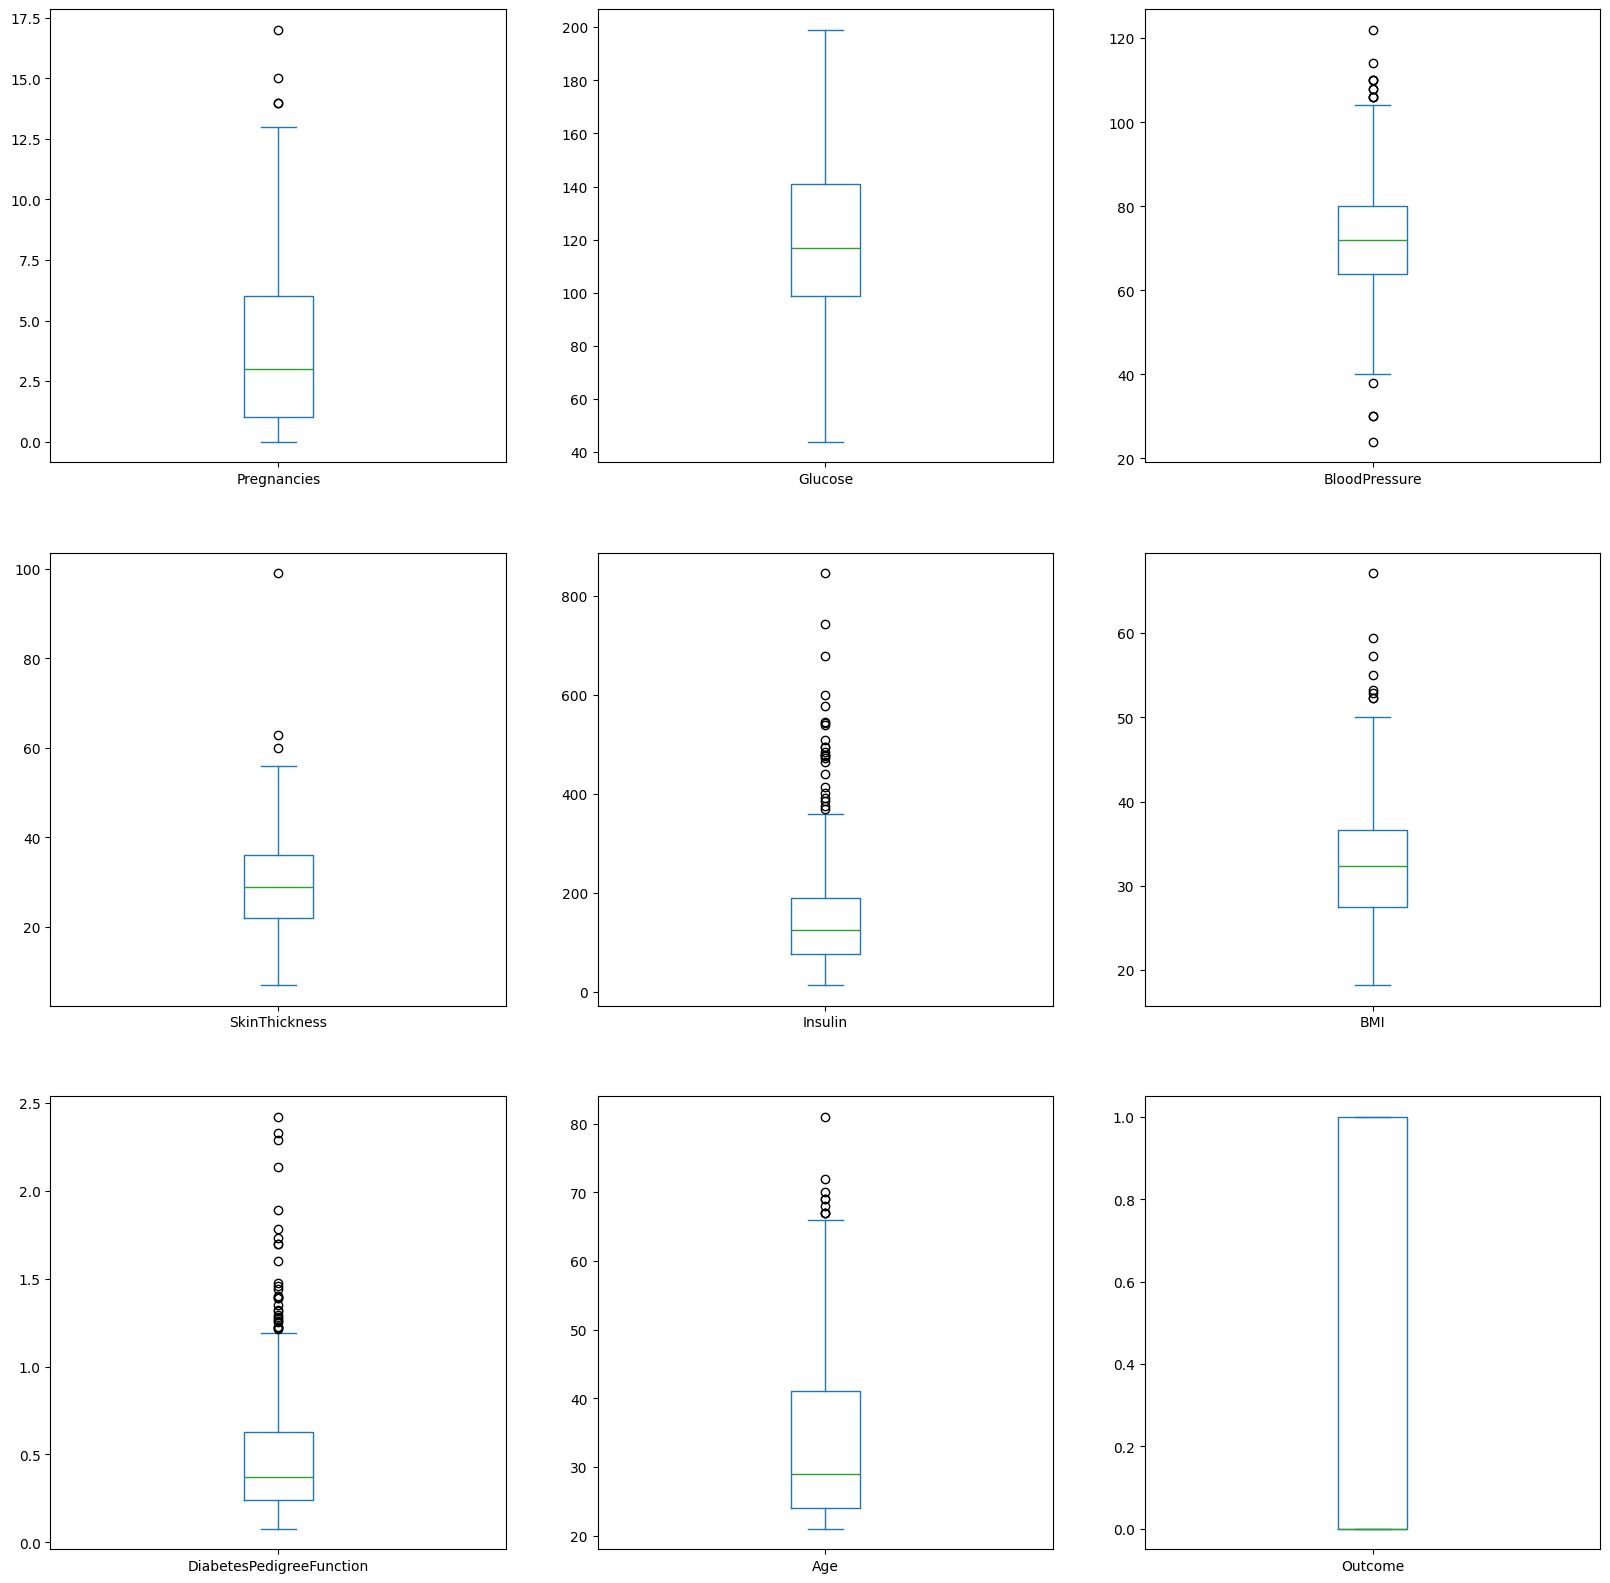

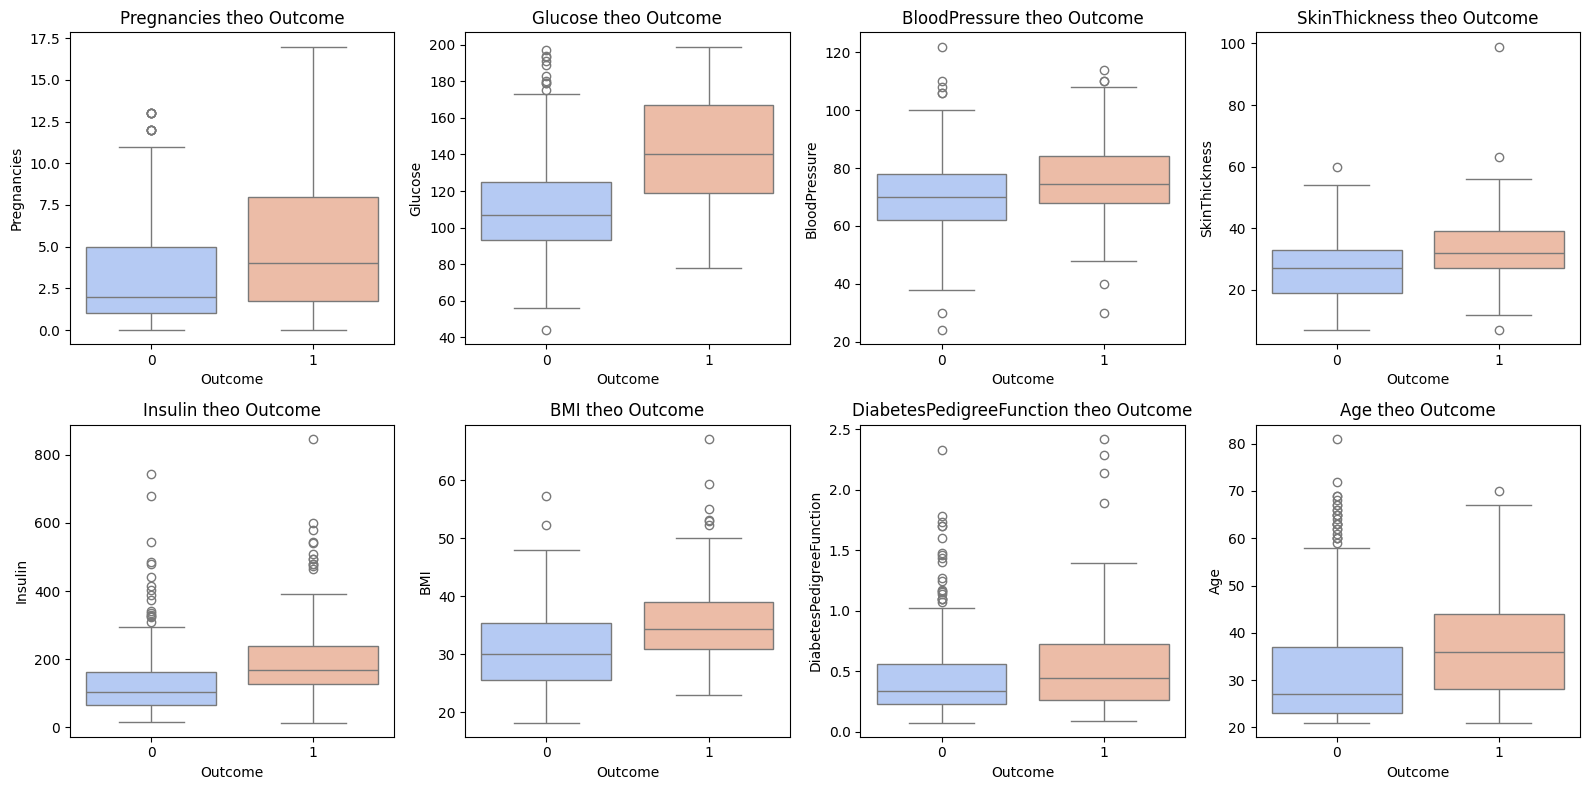

In [11]:
df.plot(figsize=(20, 20), kind='box', subplots=True, layout=(3, 3))
plt.savefig(os.path.join(report_path, "box_plots.png"), dpi=200, bbox_inches="tight")
plt.show()

# Vẽ boxplot cho từng feature theo Outcome trong khung 3x3
features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=False)
axes = axes.flatten()  # Làm phẳng để dễ loop

for i, feature in enumerate(features):
    sns.boxplot(data=df, x="Outcome", y=feature, ax=axes[i], palette="coolwarm")
    axes[i].set_title(f"{feature} theo Outcome")
    axes[i].set_xlabel("Outcome")
    axes[i].set_ylabel(feature)

plt.tight_layout()

# Lưu ảnh
plt.savefig(os.path.join(report_path, "all_features_boxplots_by_outcome.png"), dpi=200, bbox_inches="tight")

plt.show()

### 2.5 Phát hiện Outliers

Pregnancies: 4 outliers
 + Lower bound: -6.50, Upper bound: 13.50


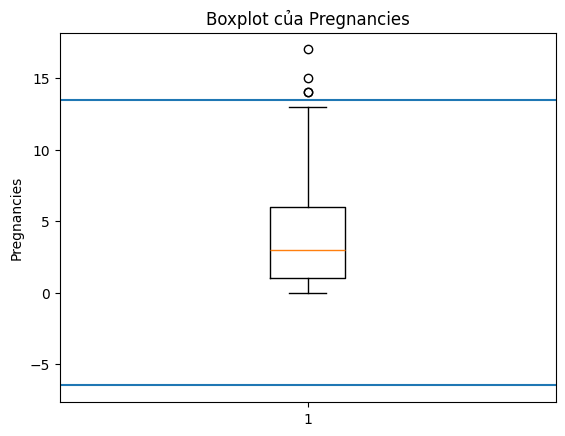

BloodPressure: 14 outliers
 + Lower bound: 40.00, Upper bound: 104.00


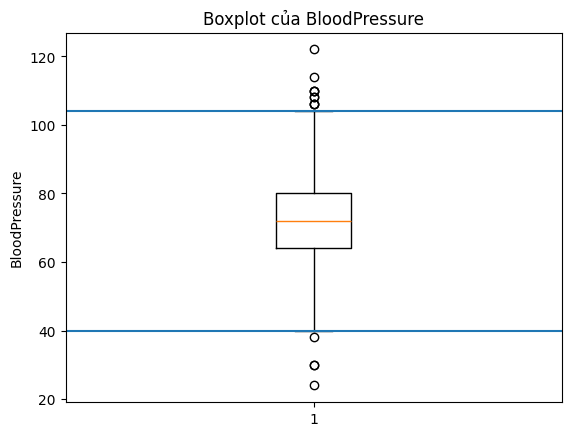

SkinThickness: 3 outliers
 + Lower bound: 1.00, Upper bound: 57.00


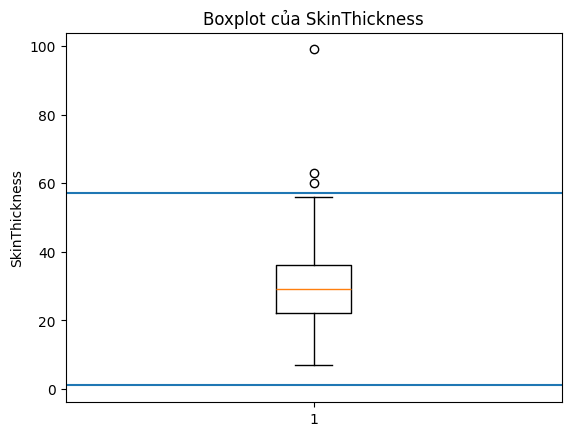

Insulin: 24 outliers
 + Lower bound: -94.38, Upper bound: 360.62


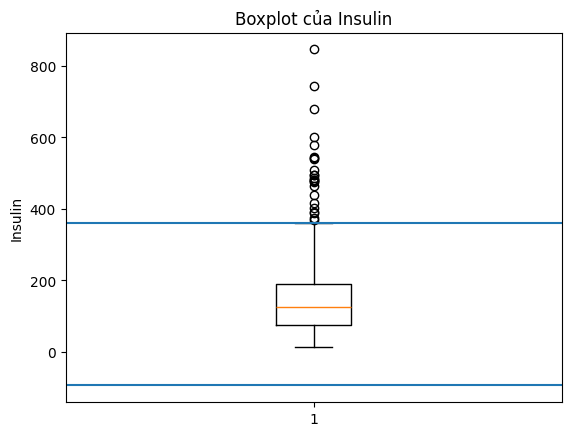

BMI: 8 outliers
 + Lower bound: 13.85, Upper bound: 50.25


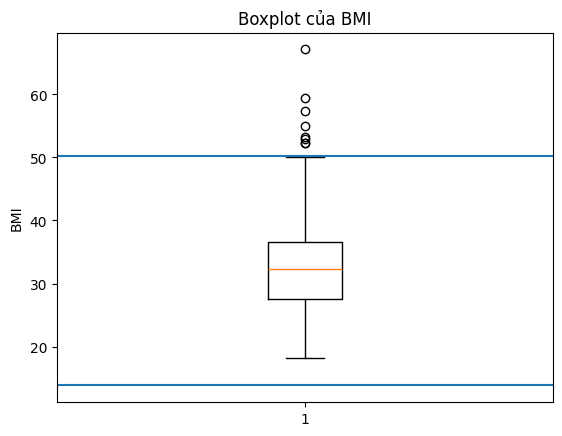

DiabetesPedigreeFunction: 29 outliers
 + Lower bound: -0.33, Upper bound: 1.20


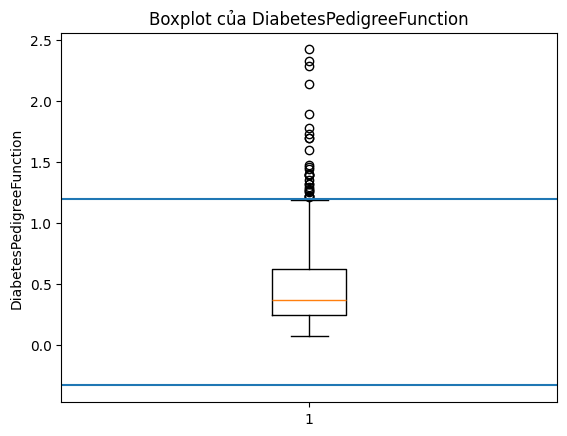

Age: 9 outliers
 + Lower bound: -1.50, Upper bound: 66.50


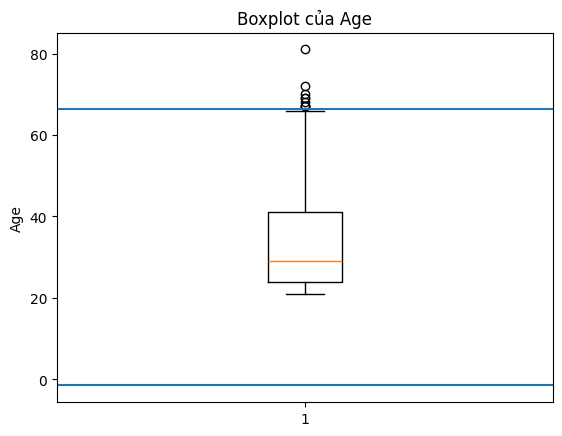

In [12]:
cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
        "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    return outliers, lower, upper

for col in cols:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    
    if not outliers.empty:
        print(f"{col}: {len(outliers)} outliers")
        print(f" + Lower bound: {lower:.2f}, Upper bound: {upper:.2f}")

        # Vẽ box plots
        plt.figure()
        plt.boxplot(df[col].dropna())
        plt.title(f"Boxplot của {col}")
        plt.ylabel(col)

        # vẽ đường ngưỡng
        plt.axhline(lower)
        plt.axhline(upper)

        plt.show()

### 2.6 Correlation matrix

Correlation matrix:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128135,0.214178,0.100239,0.082171,0.021719,-0.033523,0.544341,0.221898
Glucose,0.128135,1.000000,0.223192,0.228043,0.581186,0.232771,0.137246,0.267136,0.494650
BloodPressure,0.214178,0.223192,1.000000,0.226839,0.098272,0.289230,-0.002805,0.330107,0.170589
SkinThickness,0.100239,0.228043,0.226839,1.000000,0.184888,0.648214,0.115016,0.166816,0.259491
Insulin,0.082171,0.581186,0.098272,0.184888,1.000000,0.228050,0.130395,0.220261,0.303454
BMI,0.021719,0.232771,0.289230,0.648214,0.228050,1.000000,0.155382,0.025841,0.313680
DiabetesPedigreeFunction,-0.033523,0.137246,-0.002805,0.115016,0.130395,0.155382,1.000000,0.033561,0.173844
Age,0.544341,0.267136,0.330107,0.166816,0.220261,0.025841,0.033561,1.000000,0.238356
Outcome,0.221898,0.494650,0.170589,0.259491,0.303454,0.313680,0.173844,0.238356,1.000000


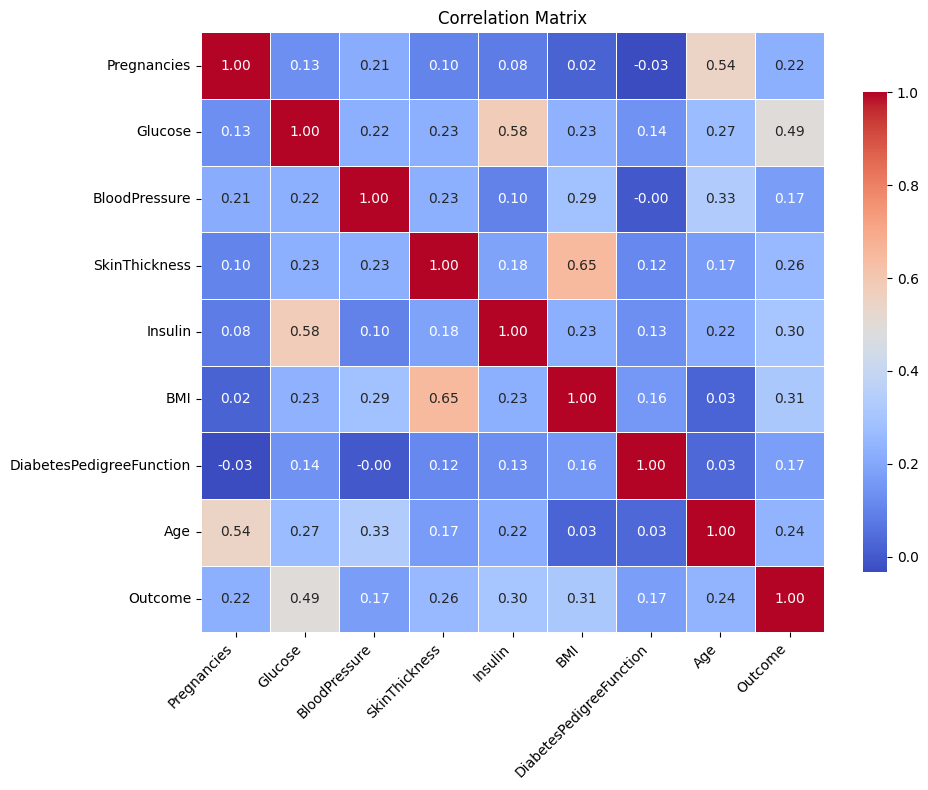


Tương quan với Outcome:
Glucose                     0.495
BMI                         0.314
Insulin                     0.303
SkinThickness               0.259
Age                         0.238
Pregnancies                 0.222
DiabetesPedigreeFunction    0.174
BloodPressure               0.171
Name: Outcome, dtype: float64


In [13]:
# Tính ma trận tương quan
corr_matrix = df.corr()

# In kết quả
print("Correlation matrix:")
display(corr_matrix)

# Vẽ heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

# Lưu biểu đồ
plt.savefig(os.path.join(report_path, "correlation_matrix.png"), dpi=200, bbox_inches="tight")

plt.show()

print("\nTương quan với Outcome:")
print(corr_matrix['Outcome'].drop('Outcome').sort_values(ascending=False).round(3))

### 2.7 Histrogram

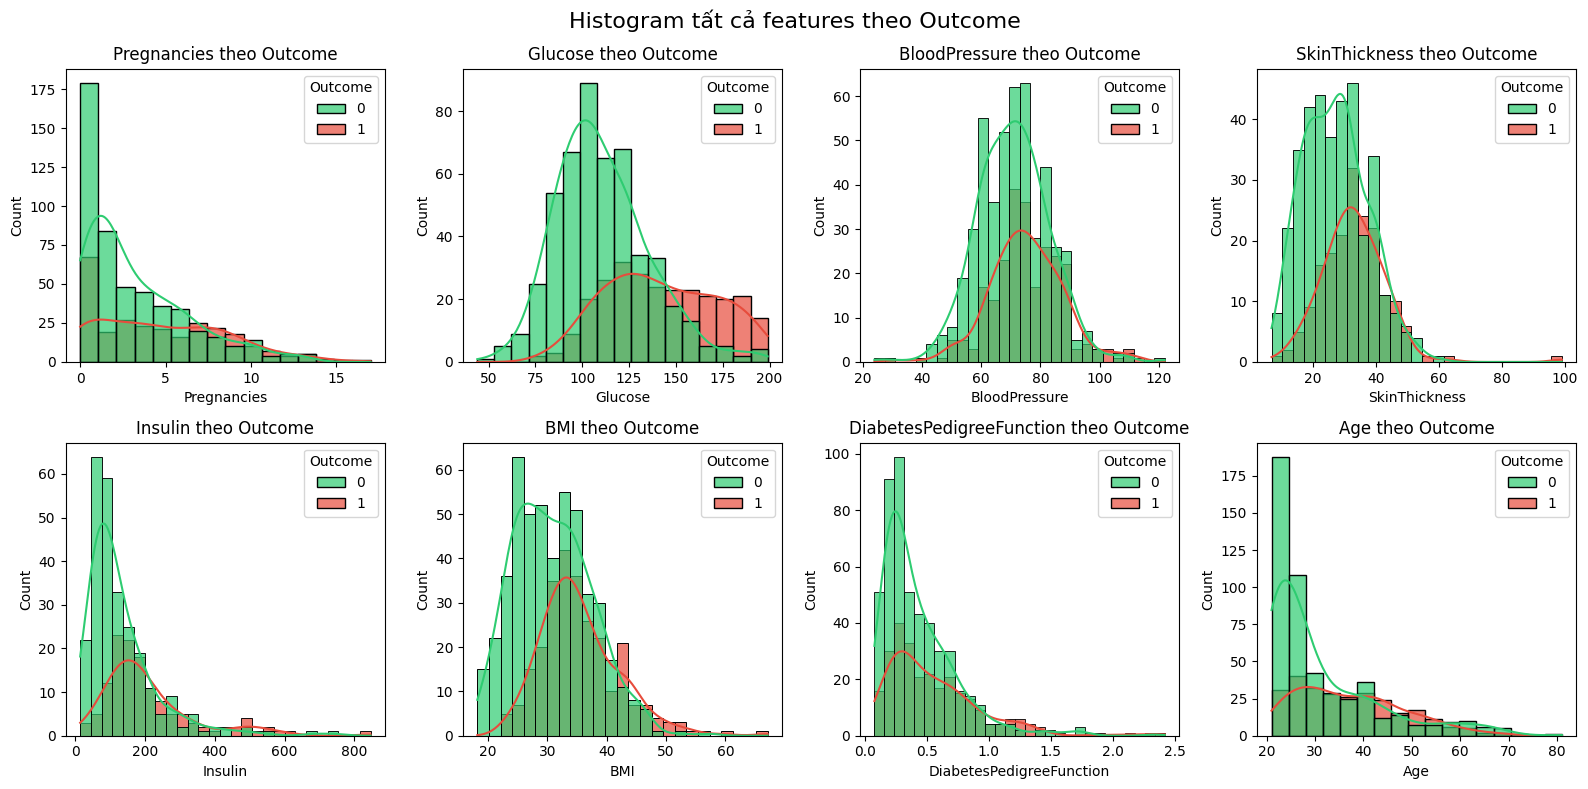

In [14]:
# Vẽ histogram cho từng feature theo Outcome
features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=False)
axes = axes.flatten()

custom_palette = {0: "#2ecc71", 1: "#e74c3c"}

for i, feature in enumerate(features):
    sns.histplot(data=df, x=feature, hue="Outcome", ax=axes[i], kde=True, palette=custom_palette, alpha=0.7)
    axes[i].set_title(f"{feature} theo Outcome")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")

plt.suptitle("Histogram tất cả features theo Outcome", fontsize=16)
plt.tight_layout()

# Lưu ảnh
plt.savefig(os.path.join(report_path, "all_features_histograms_by_outcome.png"), dpi=200, bbox_inches="tight")

plt.show()

### 2.8 Scatterplot

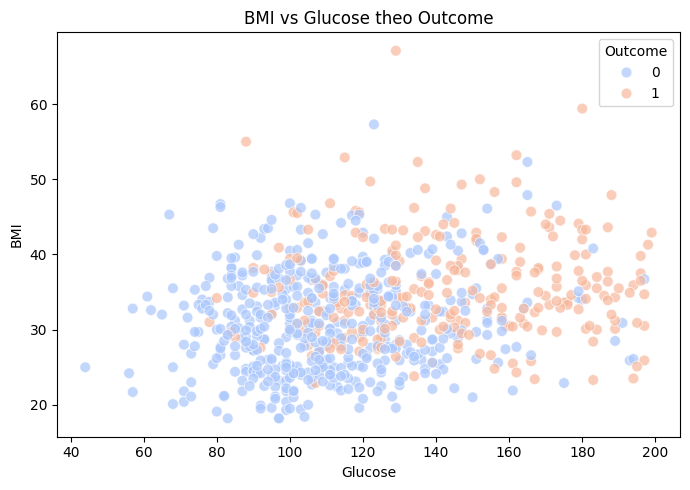

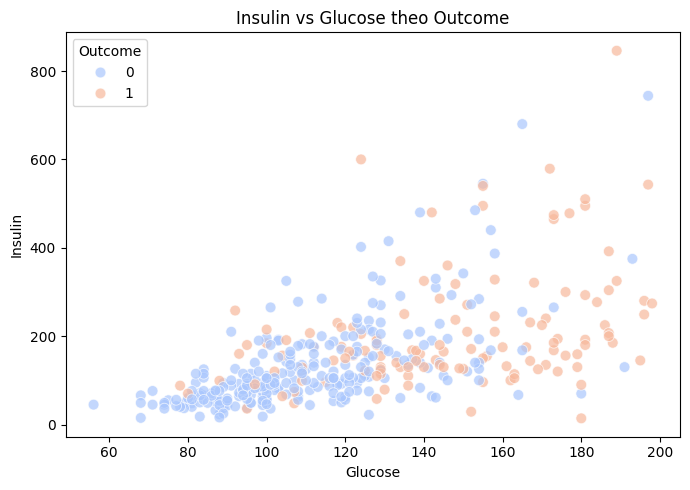

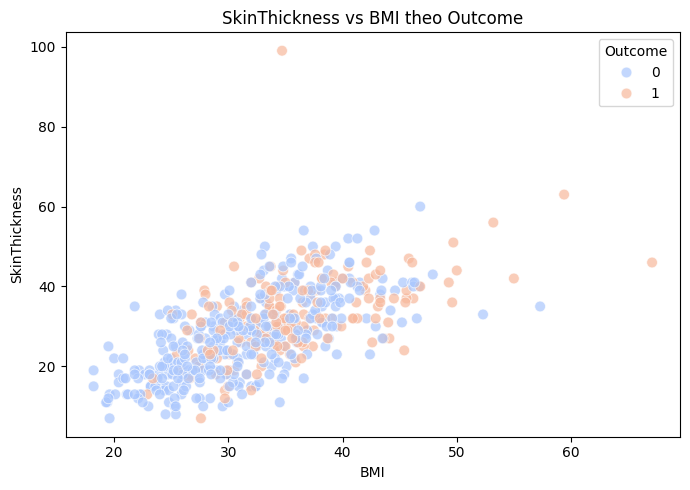

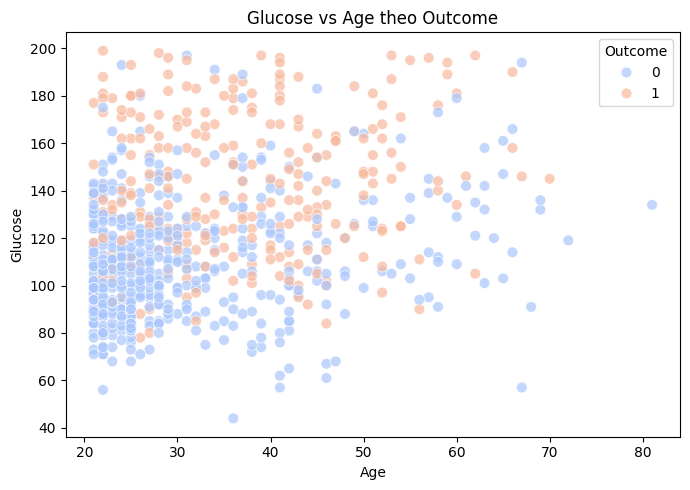

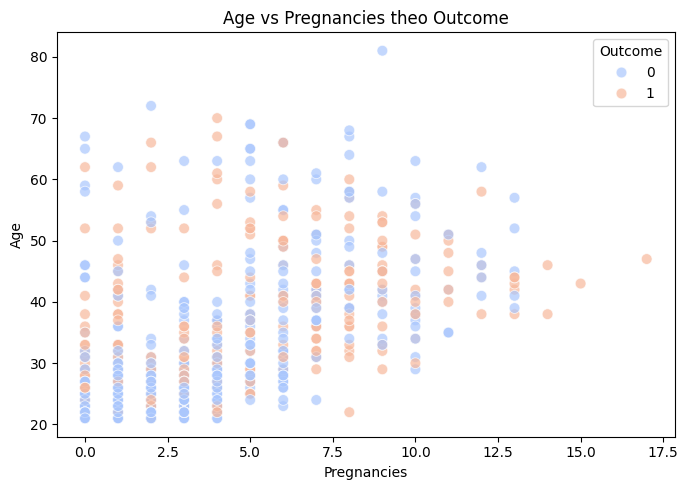

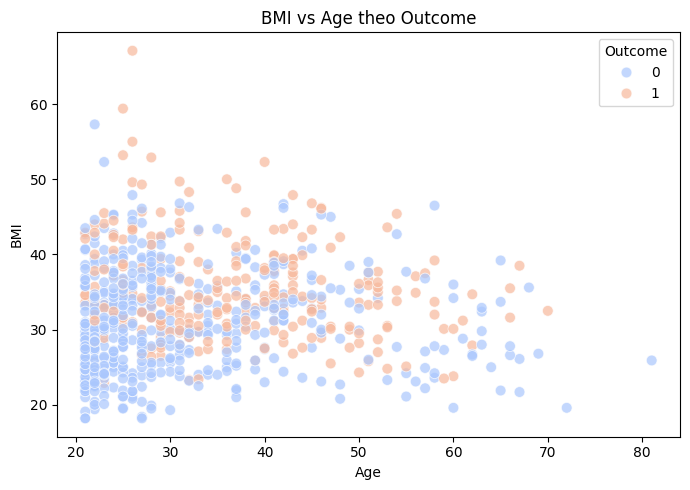

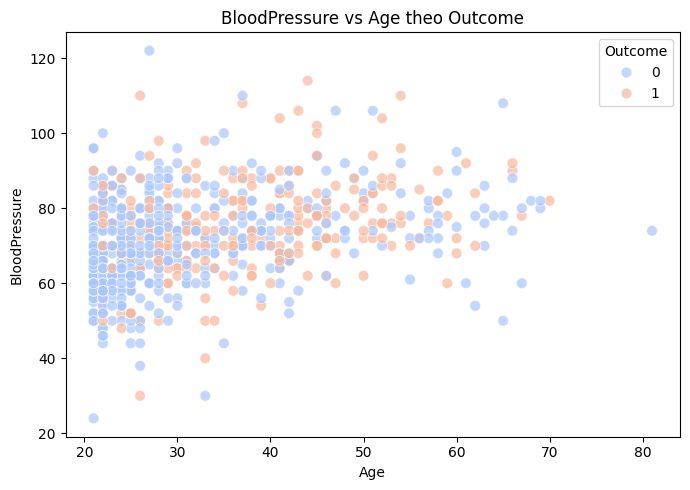

In [15]:
pairs = [
    ("Glucose", "BMI"),
    ("Glucose", "Insulin"),
    ("BMI", "SkinThickness"),
    ("Age", "Glucose"),
    ("Pregnancies", "Age"),
    ("Age", "BMI"),
    ("Age", "BloodPressure"),
]

for x_col, y_col in pairs:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue="Outcome",
        palette="coolwarm",
        alpha=0.7,
        s=60,
        edgecolor="w"
    )
    plt.title(f"{y_col} vs {x_col} theo Outcome")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend(title="Outcome", loc="best")
    plt.tight_layout()

    filename = f"scatter_{x_col.lower()}_{y_col.lower()}.png"
    plt.savefig(os.path.join(report_path, filename), dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

### 2.9 Pairplot

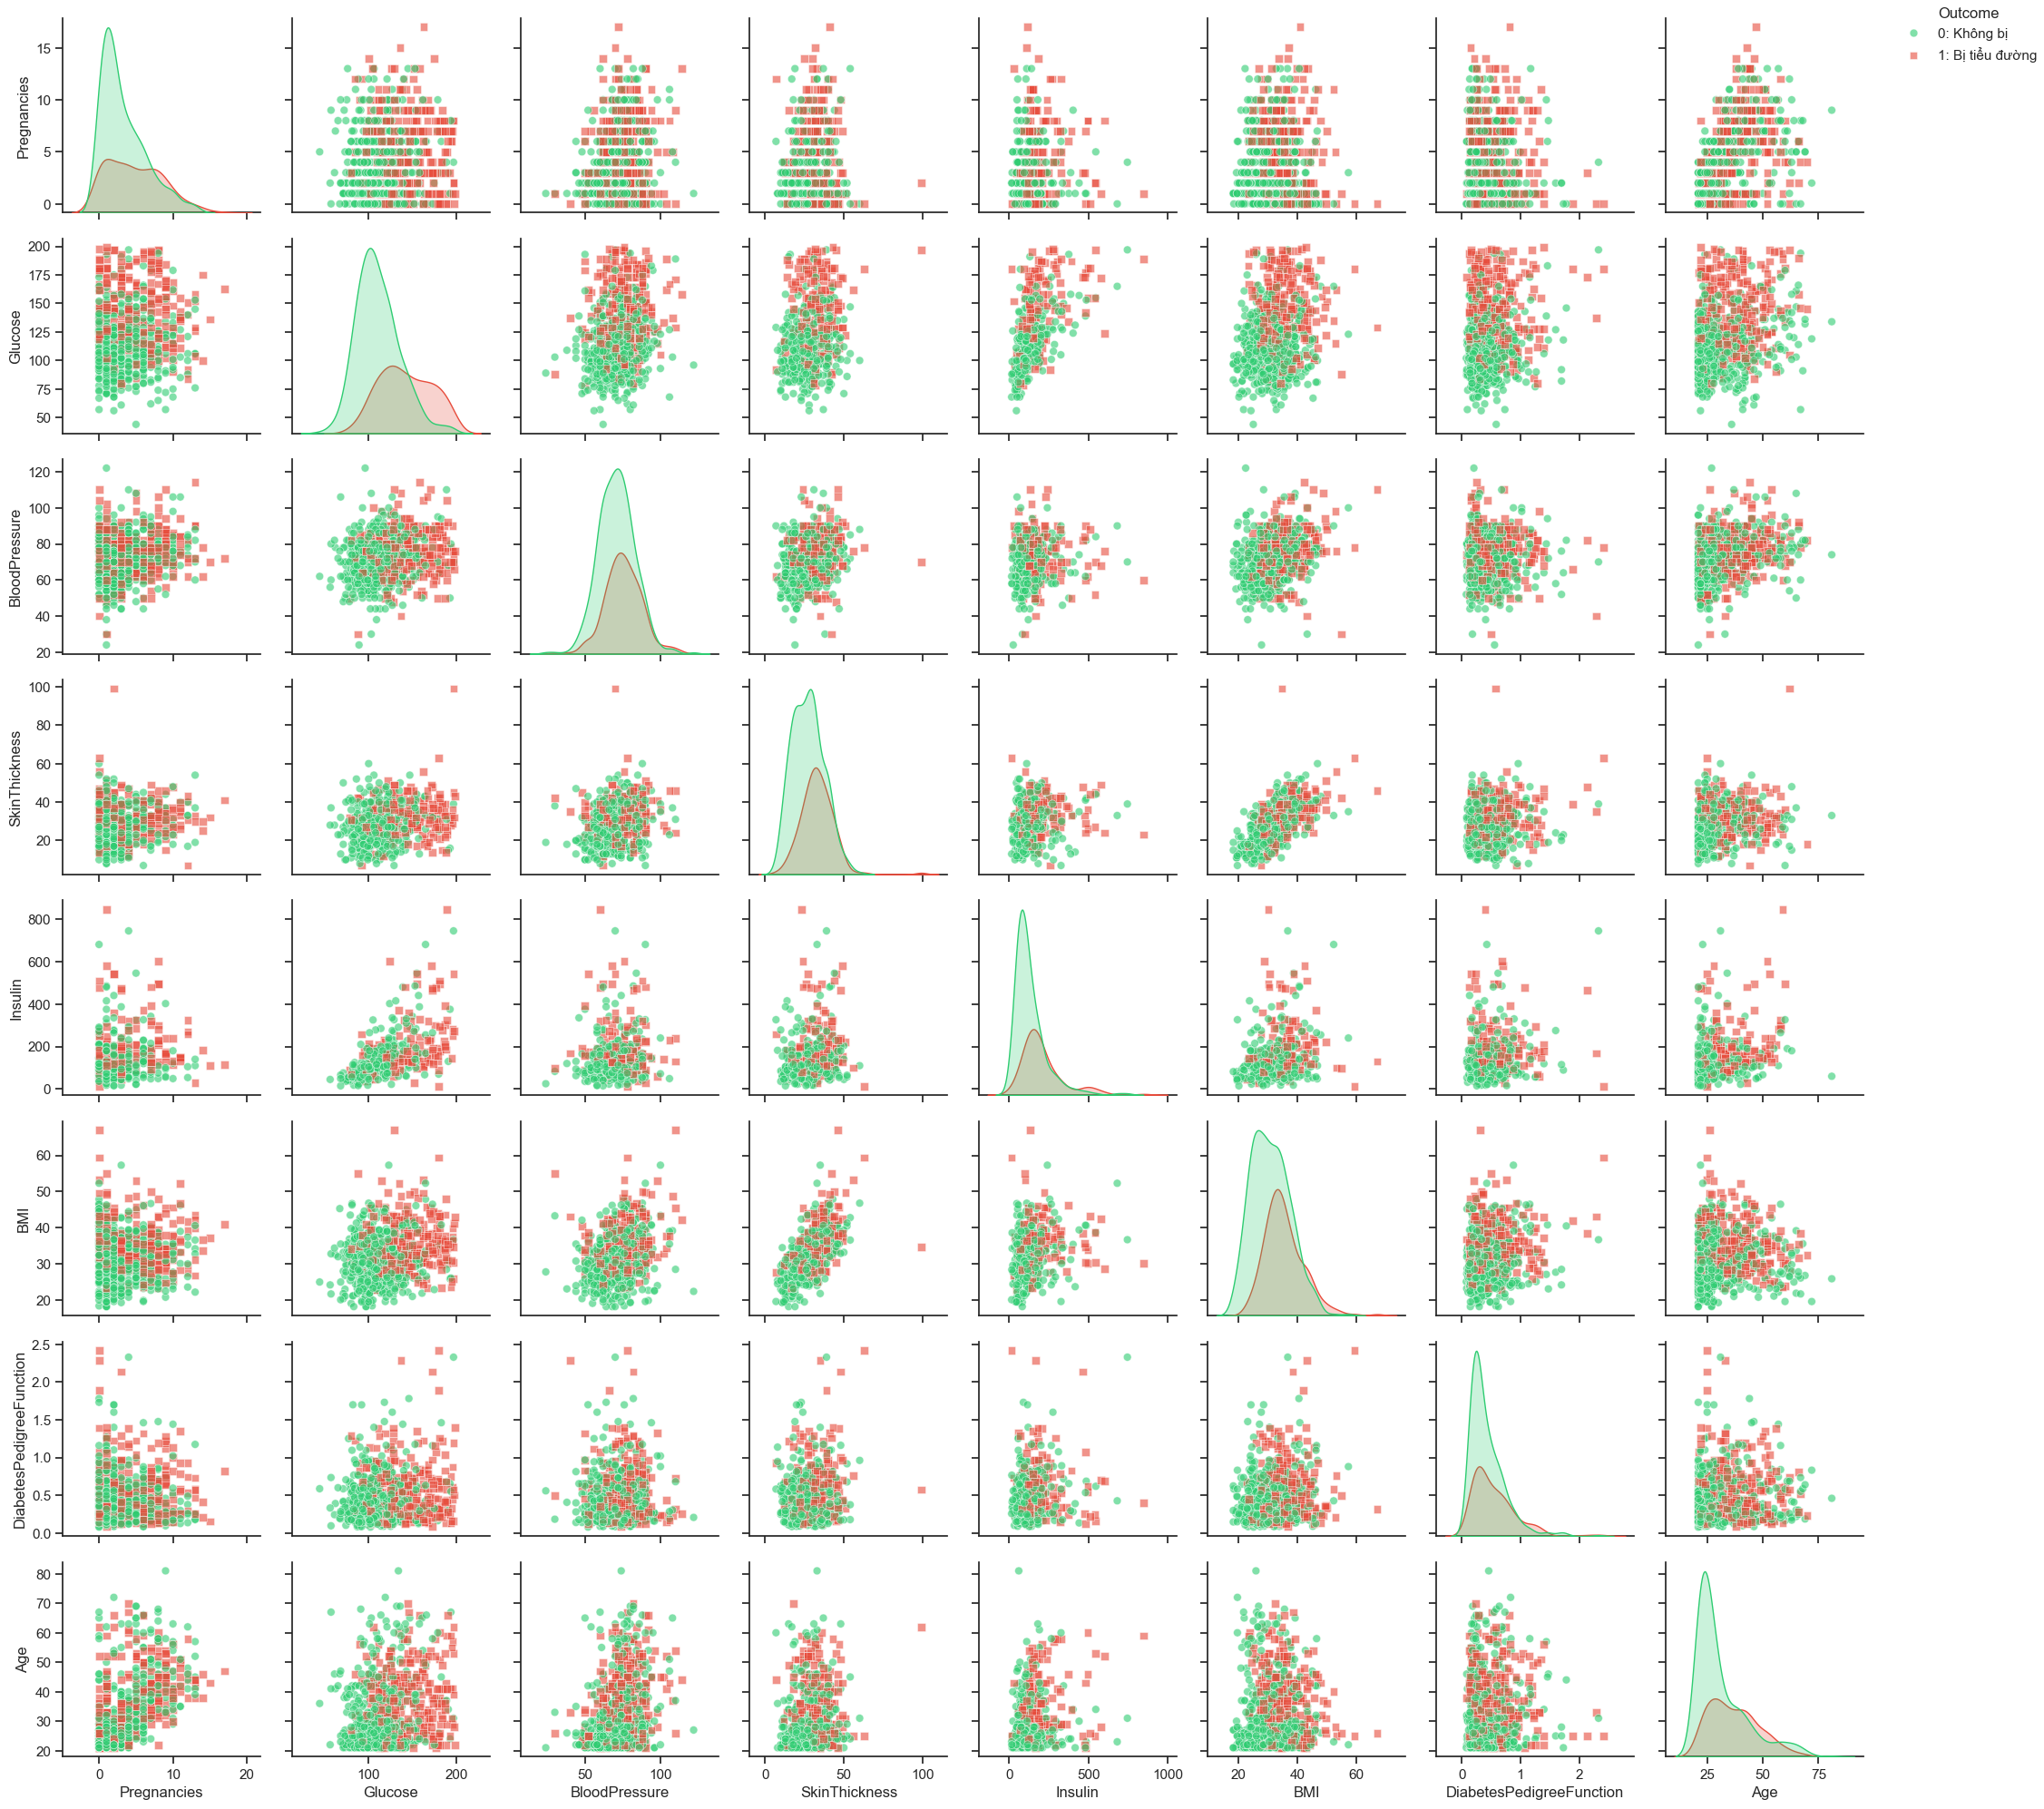

In [16]:
sns.set(style="ticks", font_scale=1.0)

pairplot = sns.pairplot(
    df,
    vars=["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"],
    hue="Outcome",
    diag_kind="kde",    # or "hist"
    palette={0: "#2ecc71", 1: "#e74c3c"},
    markers=["o", "s"],
    plot_kws={"alpha": 0.6, "s": 40}
)


for t, l in zip(pairplot._legend.texts, ["0: Không bị", "1: Bị tiểu đường"]):
    t.set_text(l)

pairplot._legend.set_bbox_to_anchor((1, 1))  # góc trên bên phải
pairplot._legend.set_loc('upper left')       # neo từ góc trái của legend


plt.tight_layout()
pairplot.savefig(os.path.join(report_path, "pairplot_features.png"), dpi=180, bbox_inches="tight")
plt.show()

# Kết thúc